# Pertemuan 6 — Praktikum 1: HDBSCAN dan Perbandingannya dengan DBSCAN

HDBSCAN (*Hierarchical Density-Based Spatial Clustering of Applications with Noise*) adalah metode klasterisasi berbasis kepadatan yang dikembangkan dari DBSCAN. HDBSCAN menambahkan pendekatan hierarki sehingga tidak memerlukan parameter radius `eps` dan lebih mampu menangani kelompok data dengan kepadatan yang berbeda.

Praktikum ini membahas pembuatan dataset sintetis, pengaruh skala data pada DBSCAN, perbandingan DBSCAN dengan HDBSCAN, serta penerapan pada data yang memiliki kepadatan berbeda. Setiap sel kode dijalankan berurutan dari atas ke bawah.

Sumber: [Praktikum 1](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-2025-2026/js05-klasterisasi-hierarki/praktikum-1).


## 1. Menyiapkan pustaka

Pustaka `hdbscan` tidak tersedia secara bawaan pada scikit-learn, sehingga perlu dipasang terpisah (pada environment ini sudah tersedia). Sel berikut memuat seluruh pustaka yang diperlukan dan menampilkan grafik langsung di dalam notebook.


In [1]:
%matplotlib inline

# Pemasangan sekali saja: pip install hdbscan
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import hdbscan


## 2. Fungsi visualisasi hasil klasterisasi

Fungsi `plot` menampilkan hasil klasterisasi dalam satu bidang dua dimensi. Titik noise (label `-1`) digambar sebagai tanda silang hitam, sedangkan titik anggota klaster digambar sebagai lingkaran yang ukurannya mengikuti nilai probabilitas keanggotaan. Judul grafik memuat jumlah klaster hasil perhitungan dan nilai parameter yang dipakai.


In [2]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # warna hitam untuk noise
        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

## 3. Membuat dataset sintetis

Dataset berisi 750 titik yang tersebar pada tiga kelompok Gaussian. Ketiga kelompok dibuat dengan simpangan baku berbeda (`0.4`, `0.1`, dan `0.75`) agar kerapatannya tidak seragam. Label asli hanya dipakai untuk menampilkan keadaan sebenarnya dan tidak diberikan ke model.


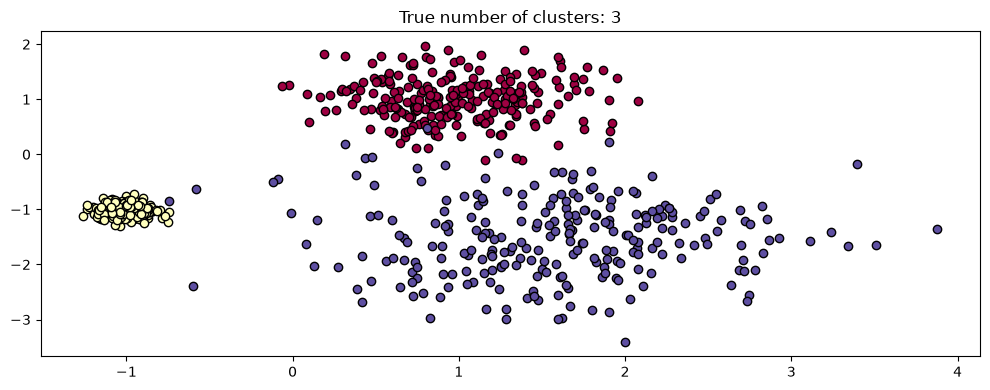

In [3]:
centers = [[1, 1], [-1, -1], [1.5, -1.5]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=[0.4, 0.1, 0.75], random_state=0
)

plot(X, labels=labels_true, ground_truth=True)
plt.show()


## 4. Pengaruh skala data pada DBSCAN

DBSCAN memakai nilai `eps` yang tetap, sehingga hasilnya bergantung pada skala data. Pada percobaan ini `eps = 0.3` dipakai untuk data yang dikalikan dengan faktor `1`, `0.5`, dan `3`. Nilai `eps` yang sama menghasilkan pembagian klaster yang berbeda karena jarak antar titik ikut berubah.


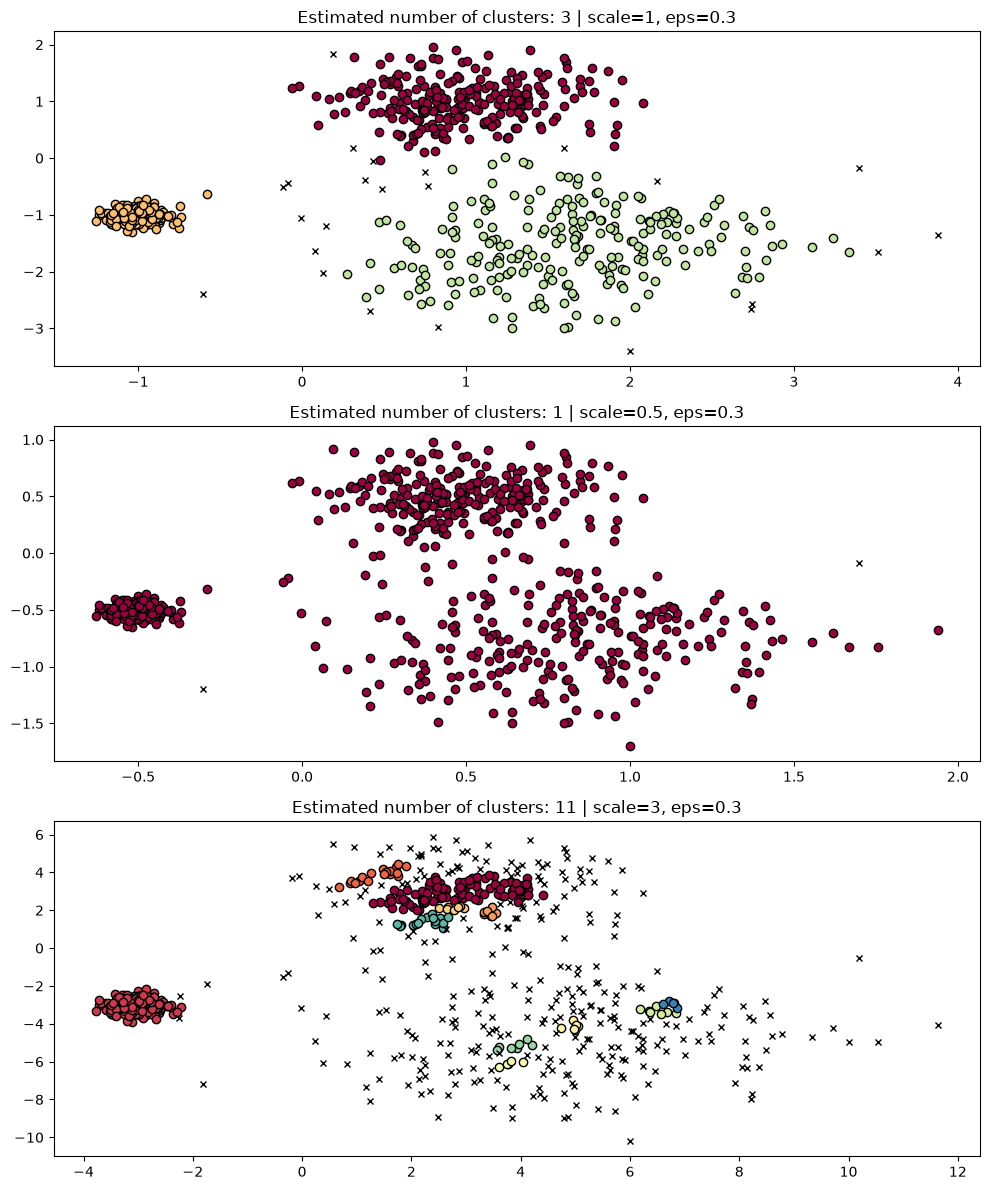

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
dbs = DBSCAN(eps=0.3)
for idx, scale in enumerate([1, 0.5, 3]):
    dbs.fit(X * scale)
    plot(X * scale, dbs.labels_, parameters={"scale": scale, "eps": 0.3}, ax=axes[idx])
plt.show()


## 5. Menyesuaikan eps dengan skala data

Hasil pada skala `3` dapat diperbaiki dengan memperbesar `eps` menjadi `0.9`. Penyesuaian ini menunjukkan bahwa nilai `eps` harus dipilih ulang setiap kali skala data berubah.


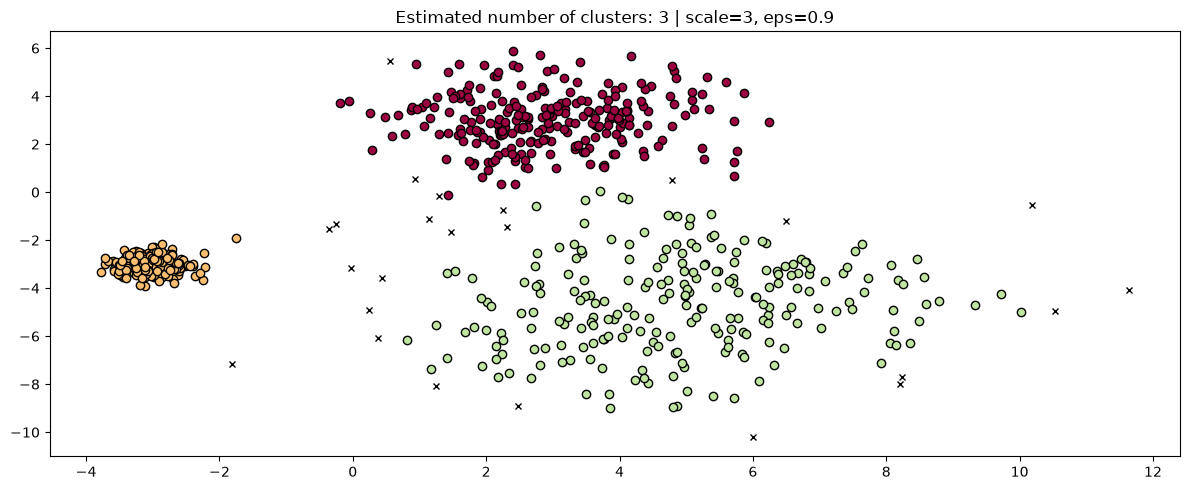

In [5]:
fig, axis = plt.subplots(1, 1, figsize=(12, 5))
dbs = DBSCAN(eps=0.9).fit(3 * X)
plot(3 * X, dbs.labels_, parameters={"scale": 3, "eps": 0.9}, ax=axis)
plt.show()


## 6. HDBSCAN pada skala data yang berbeda

HDBSCAN dijalankan pada tiga skala yang sama tanpa menentukan nilai `eps`. Pendekatan hierarki membuat hasilnya lebih stabil terhadap perubahan skala dibandingkan DBSCAN.


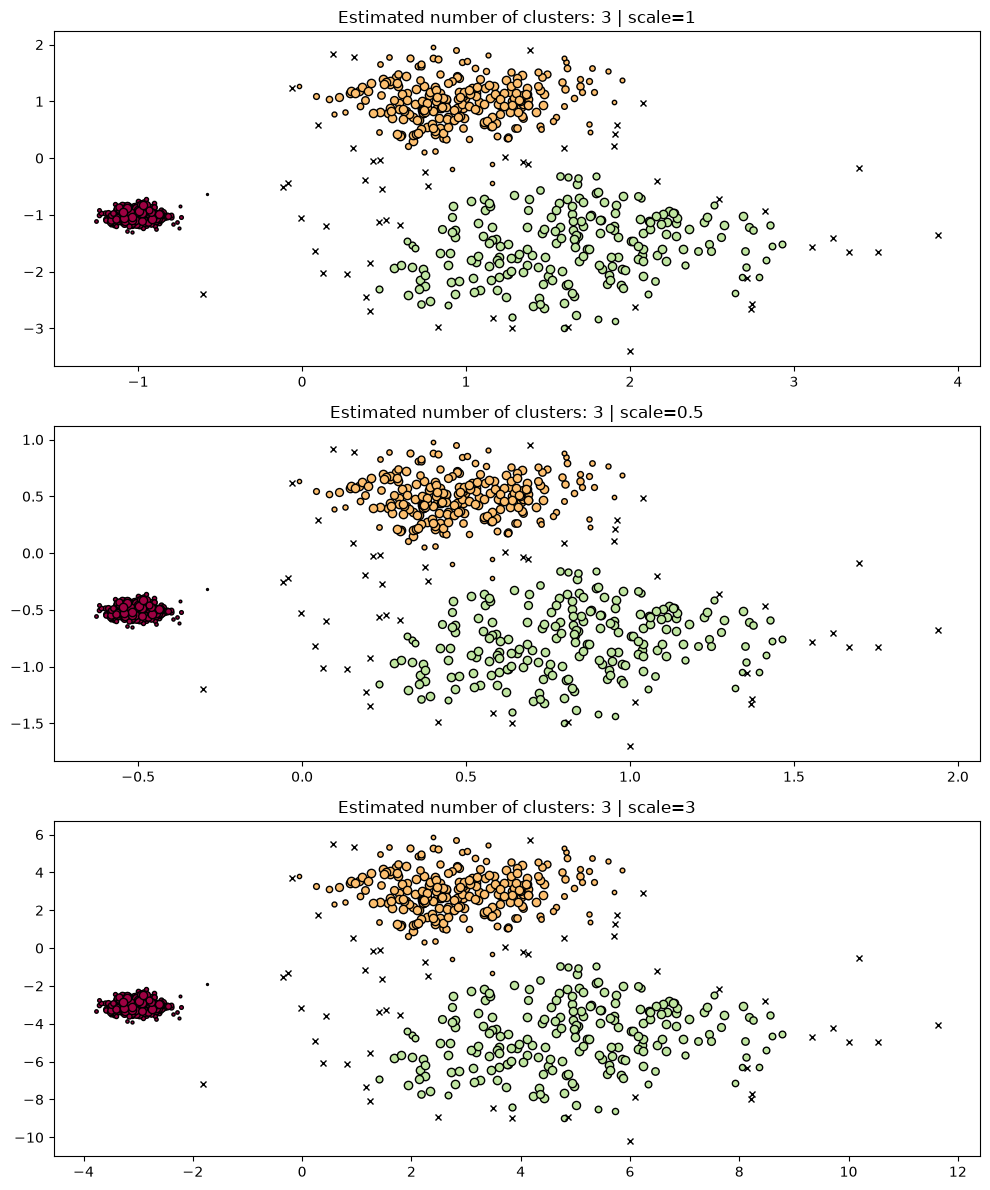

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
hdb = hdbscan.HDBSCAN()
for idx, scale in enumerate([1, 0.5, 3]):
    hdb.fit(X * scale)
    plot(X * scale, hdb.labels_, hdb.probabilities_, ax=axes[idx], parameters={"scale": scale})
plt.show()


## 7. Dataset dengan kepadatan berbeda

Data kedua berisi empat kelompok dengan tingkat kerapatan yang jauh berbeda (`0.2`, `0.35`, `1.35`, dan `1.35`). Dua kelompok berukuran rapat dan dua kelompok lain lebih menyebar. Data ini dipakai untuk menguji kemampuan kedua algoritma pada kepadatan yang tidak seragam.


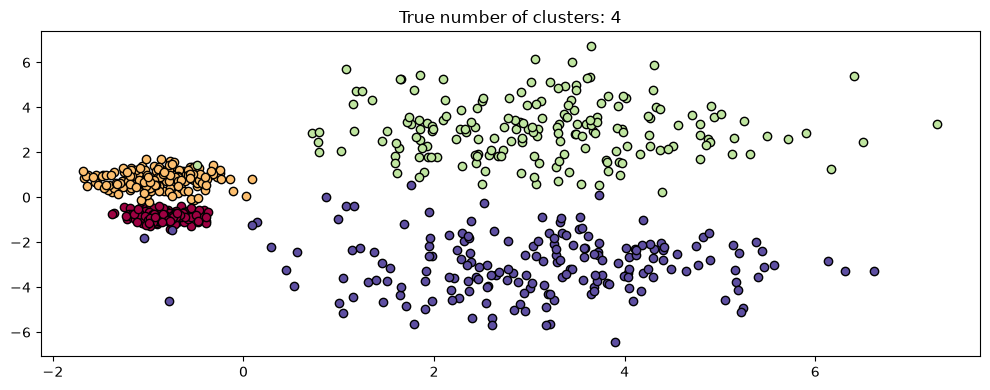

In [7]:
centers = [[-0.85, -0.85], [-0.85, 0.85], [3, 3], [3, -3]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=[0.2, 0.35, 1.35, 1.35], random_state=0
)

plot(X, labels=labels_true, ground_truth=True)
plt.show()


## 8. DBSCAN pada data dengan kepadatan berbeda

DBSCAN dicoba dengan dua nilai `eps`, yaitu `0.7` dan `0.3`. Satu nilai `eps` tidak dapat sekaligus sesuai untuk kelompok rapat dan kelompok renggang, sehingga sebagian titik cenderung masuk ke klaster yang salah atau menjadi noise.


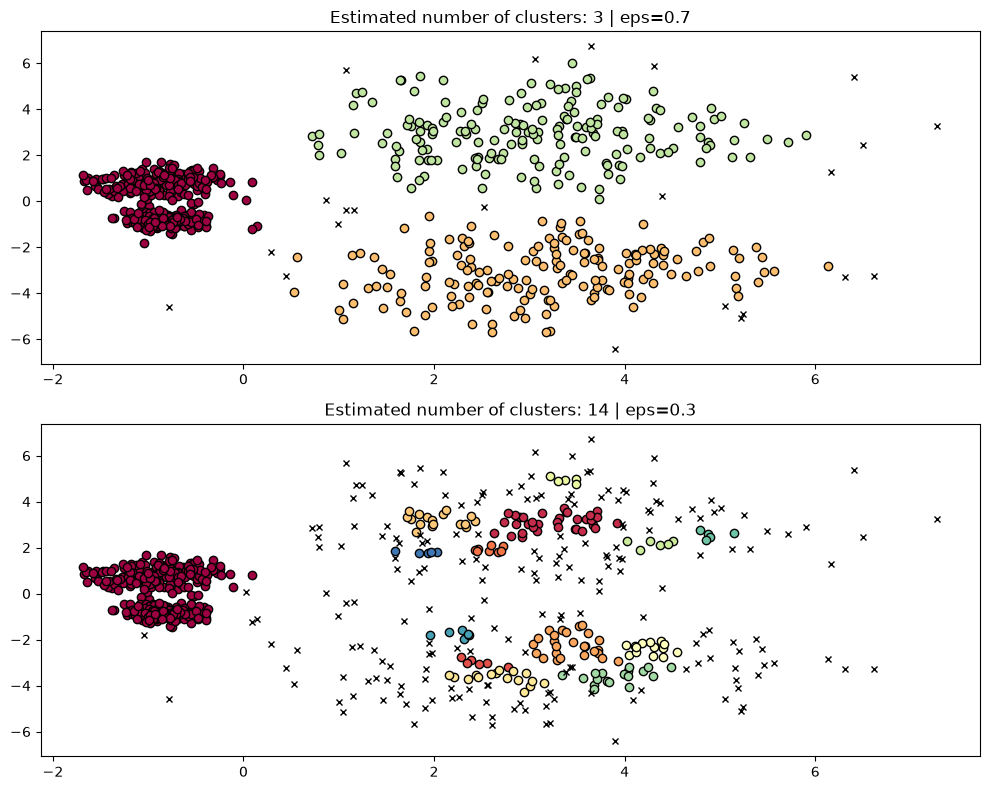

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

params = {"eps": 0.7}
dbs = DBSCAN(**params).fit(X)
plot(X, dbs.labels_, parameters=params, ax=axes[0])

params = {"eps": 0.3}
dbs = DBSCAN(**params).fit(X)
plot(X, dbs.labels_, parameters=params, ax=axes[1])
plt.show()


## 9. HDBSCAN pada data dengan kepadatan berbeda

HDBSCAN dijalankan pada data yang sama tanpa menentukan `eps`. Algoritma memilih sendiri tingkat kepadatan yang dipakai untuk memisahkan kelompok, sehingga keempat kelompok dapat dikenali dengan lebih baik.


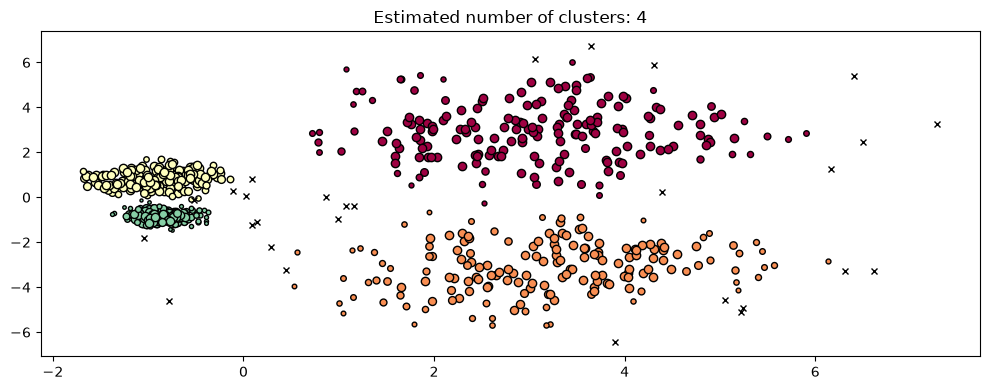

In [9]:
hdb = hdbscan.HDBSCAN().fit(X)
plot(X, hdb.labels_, hdb.probabilities_)
plt.show()


## Kesimpulan

DBSCAN sensitif terhadap skala data dan nilai `eps`, karena satu nilai radius sukar dipakai untuk kelompok dengan kepadatan yang berbeda. HDBSCAN tidak memerlukan `eps`, lebih stabil terhadap perubahan skala, dan lebih mampu memisahkan kelompok rapat dari kelompok renggang. Sebagian titik tetap dapat ditandai sebagai noise karena tidak cukup padat untuk membentuk klaster.
